In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_excel("WA_Fn-UseC_-HR-Employee-Attrition.xlsx")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
rows, cols = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {cols}")

Number of Rows    : 1470
Number of Columns : 35


In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
df.describe(include=["object","string"]).T

,count,unique,top,freq
Attrition,1470,2,No,1233
BusinessTravel,1470,3,Travel_Rarely,1043
Department,1470,3,Research & Development,961
EducationField,1470,6,Life Sciences,606
Gender,1470,2,Male,882
JobRole,1470,9,Sales Executive,326
MaritalStatus,1470,3,Married,673
Over18,1470,1,Y,1470
OverTime,1470,2,No,1054


In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing

,Missing Values,Percentage
Age,0,0.0
Attrition,0,0.0
BusinessTravel,0,0.0
DailyRate,0,0.0
Department,0,0.0
DistanceFromHome,0,0.0
Education,0,0.0
EducationField,0,0.0
EmployeeCount,0,0.0
EmployeeNumber,0,0.0


In [10]:
duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [11]:
unique_values = pd.DataFrame({
    "Unique Values": df.nunique()
})

unique_values.sort_values("Unique Values")

,Unique Values
EmployeeCount,1
Over18,1
StandardHours,1
Attrition,2
OverTime,2
PerformanceRating,2
Gender,2
BusinessTravel,3
Department,3
MaritalStatus,3


In [12]:

hr = df.copy()

hr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [13]:
print(f"Rows    : {hr.shape[0]}")
print(f"Columns : {hr.shape[1]}")

Rows    : 1470
Columns : 35


In [14]:
hr["Attrition_Binary"] = hr["Attrition"].map({
    "Yes": 1,
    "No": 0
})

hr[["Attrition", "Attrition_Binary"]].head()

,Attrition,Attrition_Binary
0,Yes,1
1,No,0
2,Yes,1
3,No,0
4,No,0


In [15]:
bins = [18, 25, 35, 45, 55, 65]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65"
]

hr["Age_Group"] = pd.cut(
    hr["Age"],
    bins=bins,
    labels=labels
)

hr[["Age", "Age_Group"]].head()

,Age,Age_Group
0,41,36-45
1,49,46-55
2,37,36-45
3,33,26-35
4,27,26-35


In [16]:
income_bins = [0, 3000, 6000, 10000, 15000, 25000]

income_labels = [
    "Low",
    "Lower Middle",
    "Middle",
    "Upper Middle",
    "High"
]

hr["Income_Band"] = pd.cut(
    hr["MonthlyIncome"],
    bins=income_bins,
    labels=income_labels
)

hr[["MonthlyIncome", "Income_Band"]].head()

,MonthlyIncome,Income_Band
0,5993,Lower Middle
1,5130,Lower Middle
2,2090,Low
3,2909,Low
4,3468,Lower Middle


In [17]:
experience_bins = [-1, 5, 10, 20, 40]

experience_labels = [
    "Beginner",
    "Intermediate",
    "Experienced",
    "Senior"
]

hr["Experience_Level"] = pd.cut(
    hr["TotalWorkingYears"],
    bins=experience_bins,
    labels=experience_labels
)

hr[["TotalWorkingYears", "Experience_Level"]].head()

,TotalWorkingYears,Experience_Level
0,8,Intermediate
1,10,Intermediate
2,7,Intermediate
3,8,Intermediate
4,6,Intermediate


In [18]:
company_bins = [-1, 2, 5, 10, 20, 40]

company_labels = [
    "0-2 Years",
    "3-5 Years",
    "6-10 Years",
    "11-20 Years",
    "20+ Years"
]

hr["Company_Tenure"] = pd.cut(
    hr["YearsAtCompany"],
    bins=company_bins,
    labels=company_labels
)

hr[["YearsAtCompany", "Company_Tenure"]].head()

,YearsAtCompany,Company_Tenure
0,6,6-10 Years
1,10,6-10 Years
2,0,0-2 Years
3,8,6-10 Years
4,2,0-2 Years


In [19]:
hr["Promotion_Status"] = np.where(
    hr["YearsSinceLastPromotion"] >= 5,
    "Promotion Due",
    "Recently Promoted"
)

hr[["YearsSinceLastPromotion", "Promotion_Status"]].head()

,YearsSinceLastPromotion,Promotion_Status
0,0,Recently Promoted
1,1,Recently Promoted
2,0,Recently Promoted
3,3,Recently Promoted
4,2,Recently Promoted


In [20]:
hr["Overtime_Flag"] = hr["OverTime"].map({
    "Yes": 1,
    "No": 0
})

hr[["OverTime", "Overtime_Flag"]].head()

,OverTime,Overtime_Flag
0,Yes,1
1,No,0
2,Yes,1
3,Yes,1
4,No,0


In [21]:
new_columns = [

    "Attrition_Binary",

    "Age_Group",

    "Income_Band",

    "Experience_Level",

    "Company_Tenure",

    "Promotion_Status",

    "Overtime_Flag"

]

hr[new_columns].head()

,Attrition_Binary,Age_Group,Income_Band,Experience_Level,Company_Tenure,Promotion_Status,Overtime_Flag
0,1,36-45,Lower Middle,Intermediate,6-10 Years,Recently Promoted,1
1,0,46-55,Lower Middle,Intermediate,6-10 Years,Recently Promoted,0
2,1,36-45,Low,Intermediate,0-2 Years,Recently Promoted,1
3,0,26-35,Low,Intermediate,6-10 Years,Recently Promoted,1
4,0,26-35,Lower Middle,Intermediate,0-2 Years,Recently Promoted,0


In [22]:
hr.dtypes

Age                            int64
Attrition                        str
BusinessTravel                   str
DailyRate                      int64
Department                       str
DistanceFromHome               int64
Education                      int64
EducationField                   str
EmployeeCount                  int64
EmployeeNumber                 int64
EnvironmentSatisfaction        int64
Gender                           str
HourlyRate                     int64
JobInvolvement                 int64
JobLevel                       int64
JobRole                          str
JobSatisfaction                int64
MaritalStatus                    str
MonthlyIncome                  int64
MonthlyRate                    int64
NumCompaniesWorked             int64
Over18                           str
OverTime                         str
PercentSalaryHike              int64
PerformanceRating              int64
RelationshipSatisfaction       int64
StandardHours                  int64
S

In [23]:
feature_summary = pd.DataFrame({
    "Data Type": hr.dtypes,
    "Unique Values": hr.nunique()
})

feature_summary

,Data Type,Unique Values
Age,int64,43
Attrition,str,2
BusinessTravel,str,3
DailyRate,int64,886
Department,str,3
DistanceFromHome,int64,29
Education,int64,5
EducationField,str,6
EmployeeCount,int64,1
EmployeeNumber,int64,1470


In [24]:
hr.to_csv("HR_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [25]:
print("="*40)
print("TOTAL EMPLOYEES")
print("="*40)

print("Total Employees :", len(hr))

TOTAL EMPLOYEES
Total Employees : 1470


In [26]:
gender = hr["Gender"].value_counts()

gender

Gender
Male      882
Female    588
Name: count, dtype: int64

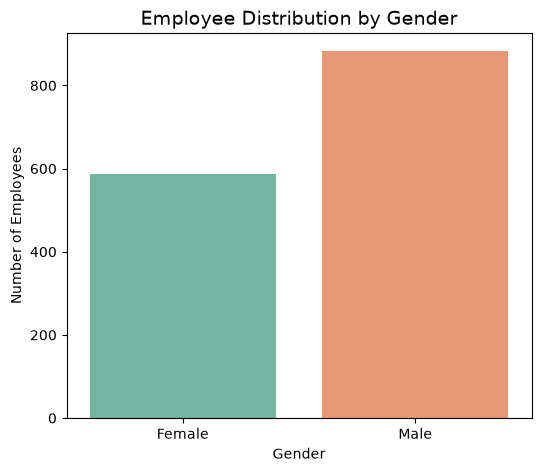

In [27]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=hr,
    x="Gender",
    hue="Gender",
    palette="Set2",
    legend=False
)

plt.title("Employee Distribution by Gender", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Number of Employees")

plt.show()

In [28]:
hr["Age"].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

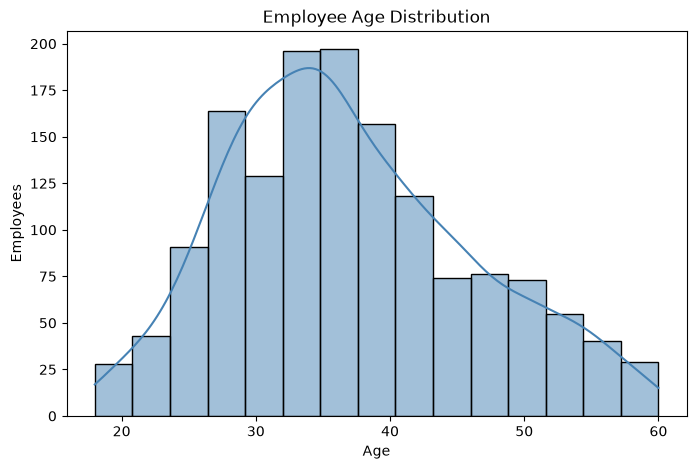

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=hr,
    x="Age",
    bins=15,
    kde=True,
    color="steelblue"
)

plt.title("Employee Age Distribution")
plt.xlabel("Age")
plt.ylabel("Employees")

plt.show()

In [30]:
age_group = hr["Age_Group"].value_counts().sort_index()

age_group

Age_Group
18-25    115
26-35    606
36-45    468
46-55    226
56-65     47
Name: count, dtype: int64

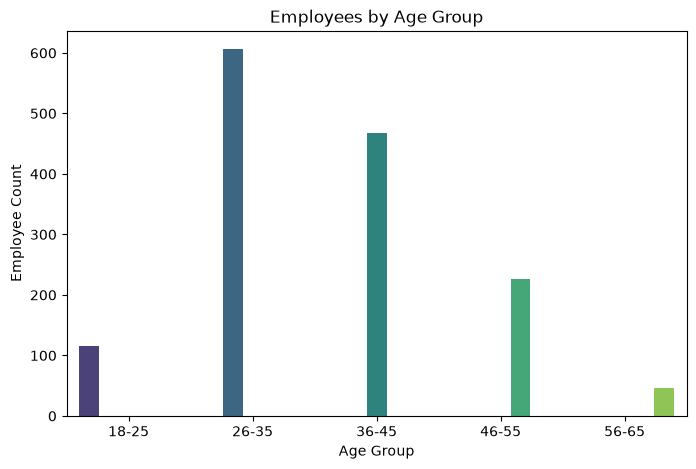

In [31]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=hr,
    x="Age_Group",
    order=age_group.index,
    hue="Age_Group",
    palette="viridis",
    legend=False
)

plt.title("Employees by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Employee Count")

plt.show()

In [32]:
marital = hr["MaritalStatus"].value_counts()

marital

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

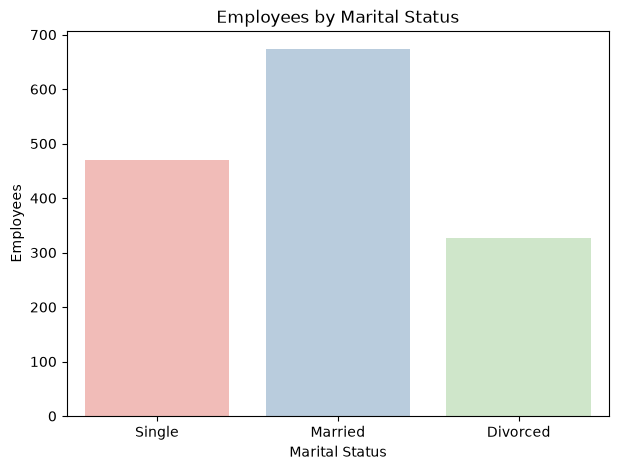

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=hr,
    x="MaritalStatus",
    hue="MaritalStatus",
    palette="Pastel1",
    legend=False
)

plt.title("Employees by Marital Status")
plt.xlabel("Marital Status")
plt.ylabel("Employees")

plt.show()

In [34]:
education = hr["Education"].value_counts().sort_index()

education

Education
1    170
2    282
3    572
4    398
5     48
Name: count, dtype: int64

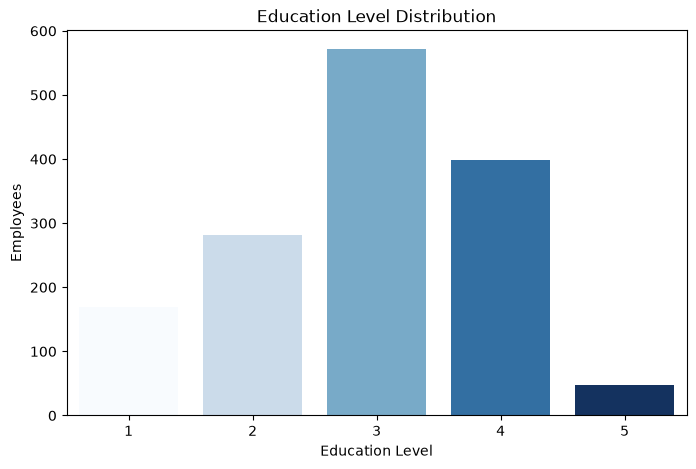

In [35]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=hr,
    x="Education",
    hue="Education",
    palette="Blues",
    legend=False
)

plt.title("Education Level Distribution")
plt.xlabel("Education Level")
plt.ylabel("Employees")

plt.show()

In [36]:
education_field = hr["EducationField"].value_counts()

education_field

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

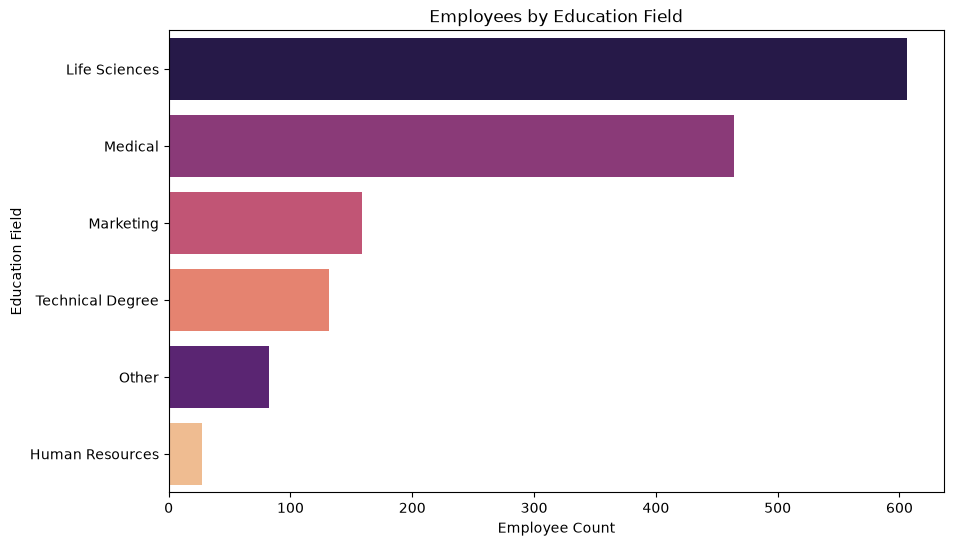

In [37]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=hr,
    y="EducationField",
    order=education_field.index,
    hue="EducationField",
    palette="magma",
    legend=False
)

plt.title("Employees by Education Field")
plt.xlabel("Employee Count")
plt.ylabel("Education Field")

plt.show()

In [38]:
department = hr["Department"].value_counts()

department

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

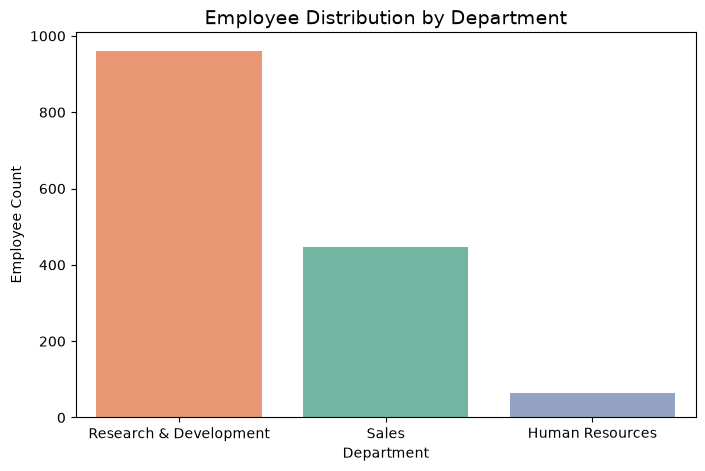

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=hr,
    x="Department",
    hue="Department",
    order=department.index,
    palette="Set2",
    legend=False
)

plt.title("Employee Distribution by Department", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Employee Count")

plt.show()

In [41]:
jobrole = hr["JobRole"].value_counts()

jobrole

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

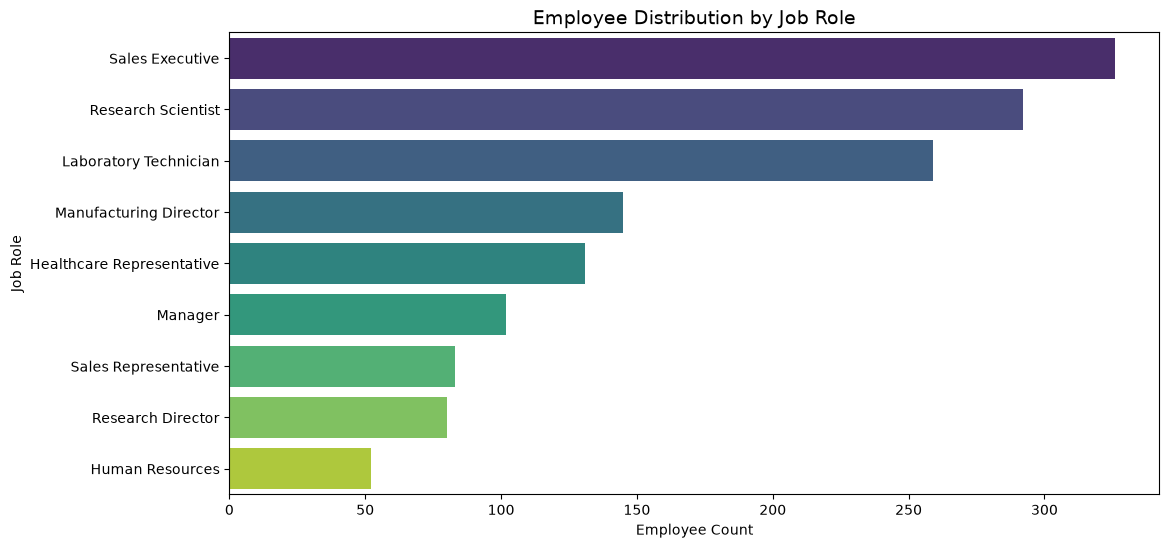

In [42]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=hr,
    y="JobRole",
    hue="JobRole",
    order=jobrole.index,
    palette="viridis",
    legend=False
)

plt.title("Employee Distribution by Job Role", fontsize=14)
plt.xlabel("Employee Count")
plt.ylabel("Job Role")

plt.show()

In [43]:
job_level = hr["JobLevel"].value_counts().sort_index()

job_level

JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64

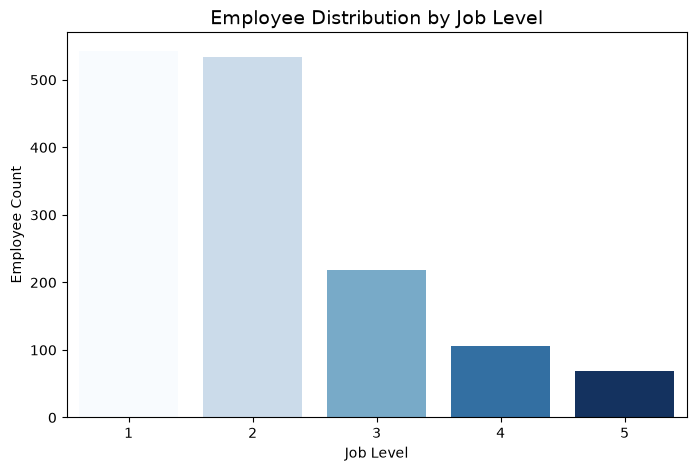

In [44]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=hr,
    x="JobLevel",
    hue="JobLevel",
    order=job_level.index,
    palette="Blues",
    legend=False
)

plt.title("Employee Distribution by Job Level", fontsize=14)
plt.xlabel("Job Level")
plt.ylabel("Employee Count")

plt.show()

In [45]:
travel = hr["BusinessTravel"].value_counts()

travel

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

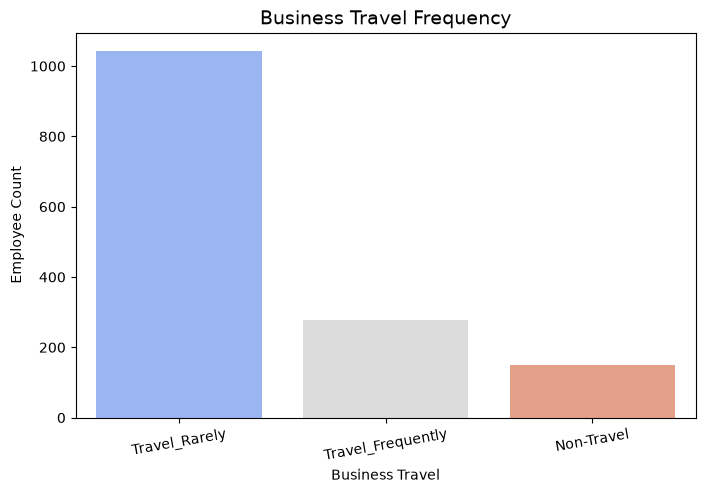

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=hr,
    x="BusinessTravel",
    hue="BusinessTravel",
    order=travel.index,
    palette="coolwarm",
    legend=False
)

plt.title("Business Travel Frequency", fontsize=14)
plt.xlabel("Business Travel")
plt.ylabel("Employee Count")

plt.xticks(rotation=10)

plt.show()

In [47]:
overtime = hr["OverTime"].value_counts()

overtime

OverTime
No     1054
Yes     416
Name: count, dtype: int64

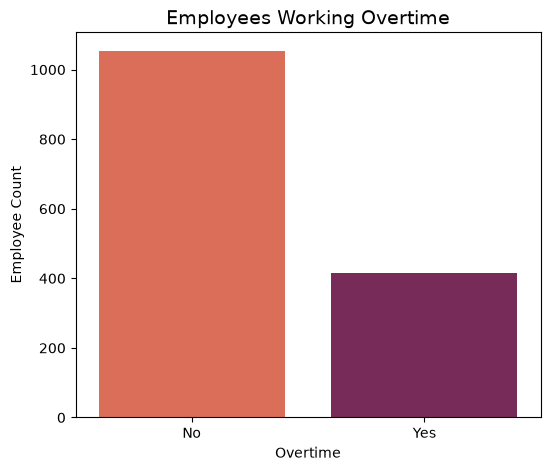

In [48]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=hr,
    x="OverTime",
    hue="OverTime",
    order=overtime.index,
    palette="rocket",
    legend=False
)

plt.title("Employees Working Overtime", fontsize=14)
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.show()

In [49]:
hr["MonthlyIncome"].describe()

count     1470.000000
mean      6502.931293
std       4707.956783
min       1009.000000
25%       2911.000000
50%       4919.000000
75%       8379.000000
max      19999.000000
Name: MonthlyIncome, dtype: float64

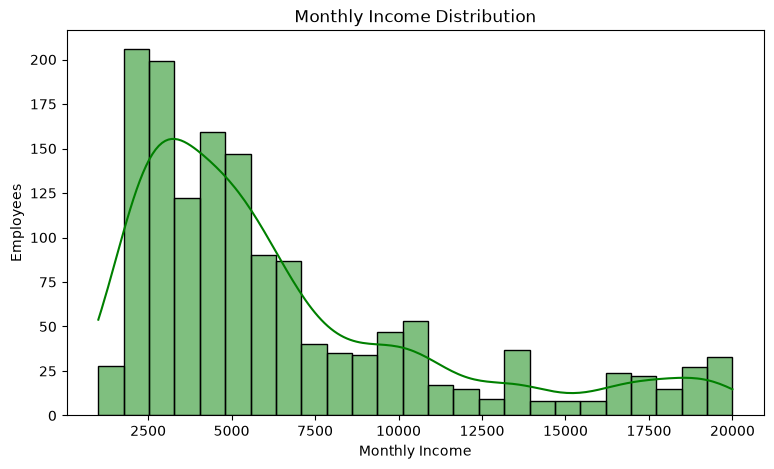

In [50]:
plt.figure(figsize=(9,5))

sns.histplot(
    data=hr,
    x="MonthlyIncome",
    bins=25,
    kde=True,
    color="green"
)

plt.title("Monthly Income Distribution")
plt.xlabel("Monthly Income")
plt.ylabel("Employees")

plt.show()

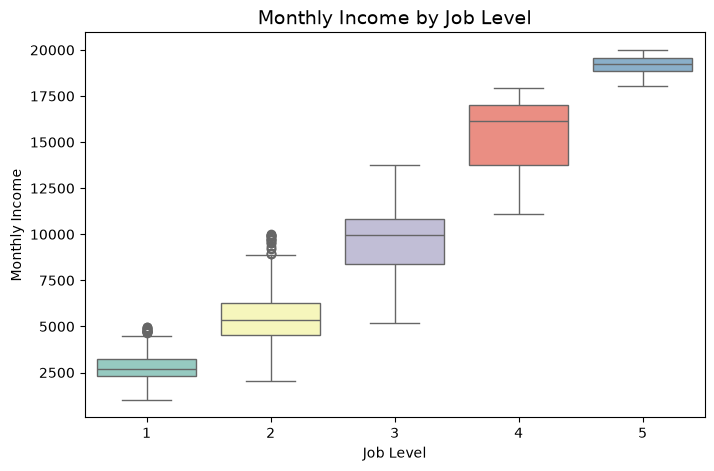

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=hr,
    x="JobLevel",
    y="MonthlyIncome",
    hue="JobLevel",
    palette="Set3",
    legend=False
)

plt.title("Monthly Income by Job Level", fontsize=14)
plt.xlabel("Job Level")
plt.ylabel("Monthly Income")

plt.show()

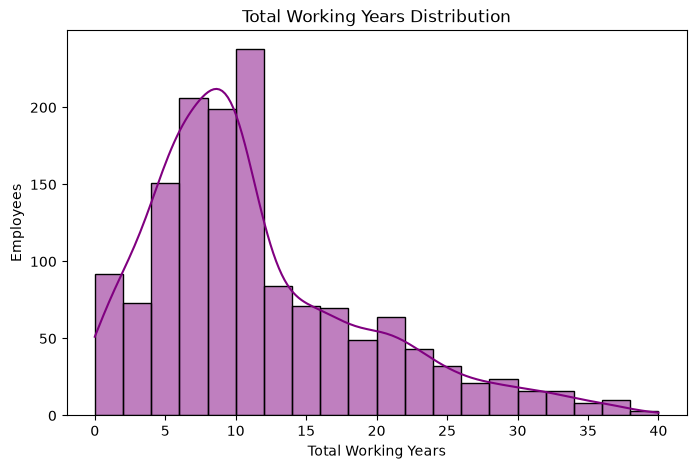

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=hr,
    x="TotalWorkingYears",
    bins=20,
    kde=True,
    color="purple"
)

plt.title("Total Working Years Distribution")
plt.xlabel("Total Working Years")
plt.ylabel("Employees")

plt.show()

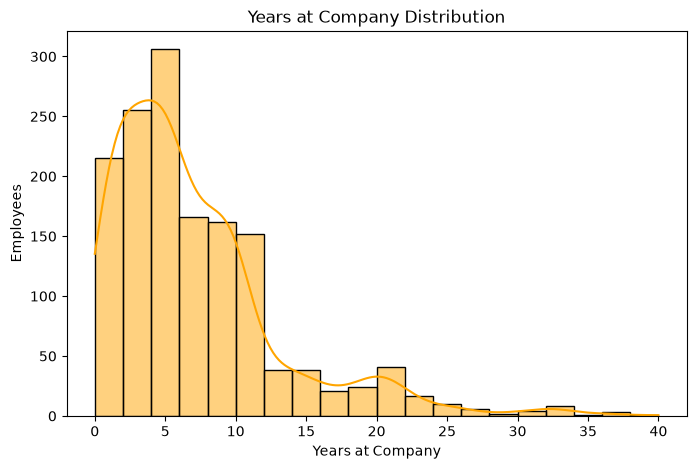

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=hr,
    x="YearsAtCompany",
    bins=20,
    kde=True,
    color="orange"
)

plt.title("Years at Company Distribution")
plt.xlabel("Years at Company")
plt.ylabel("Employees")

plt.show()

In [54]:
attrition_rate = hr["Attrition_Binary"].mean() * 100

print("="*40)
print(f"Overall Attrition Rate : {attrition_rate:.2f}%")
print("="*40)

Overall Attrition Rate : 16.12%


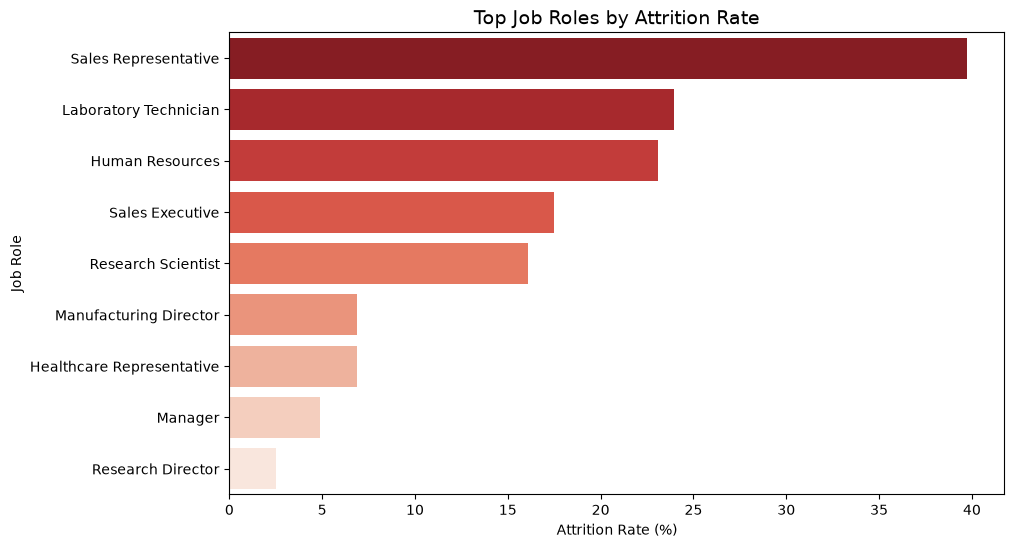

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition_Binary, dtype: float64

In [55]:
job_attrition = (
    hr.groupby("JobRole")["Attrition_Binary"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=job_attrition.values,
    y=job_attrition.index,
    hue=job_attrition.index,
    palette="Reds_r",
    legend=False
)

plt.title("Top Job Roles by Attrition Rate", fontsize=14)
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

job_attrition

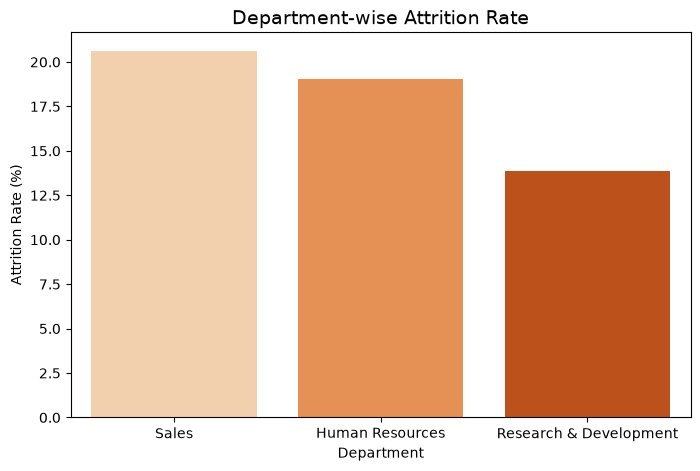

In [56]:
dept_attrition = (
    hr.groupby("Department")["Attrition_Binary"]
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=dept_attrition.index,
    y=dept_attrition.values,
    hue=dept_attrition.index,
    palette="Oranges",
    legend=False
)

plt.title("Department-wise Attrition Rate", fontsize=14)
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.show()

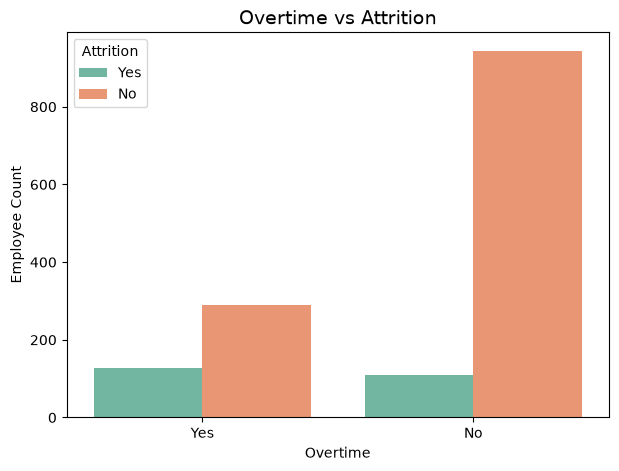

In [57]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=hr,
    x="OverTime",
    hue="Attrition",
    palette="Set2"
)

plt.title("Overtime vs Attrition", fontsize=14)
plt.xlabel("Overtime")
plt.ylabel("Employee Count")

plt.show()

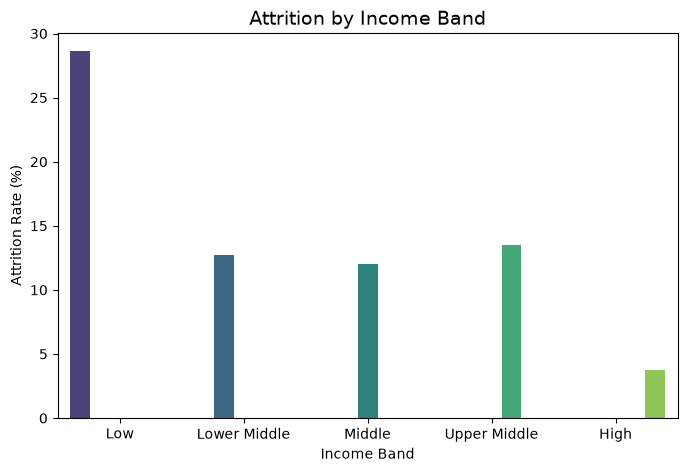

In [58]:
income_attrition = (
    hr.groupby("Income_Band")["Attrition_Binary"]
      .mean() * 100
)

plt.figure(figsize=(8,5))

sns.barplot(
    x=income_attrition.index,
    y=income_attrition.values,
    hue=income_attrition.index,
    palette="viridis",
    legend=False
)

plt.title("Attrition by Income Band", fontsize=14)
plt.xlabel("Income Band")
plt.ylabel("Attrition Rate (%)")

plt.show()

In [59]:
high_risk = (
    hr.groupby(["Department", "JobRole"])
      .agg(
          Employees=("Attrition", "count"),
          Attrition_Rate=("Attrition_Binary", "mean")
      )
)

high_risk["Attrition_Rate"] *= 100

high_risk = high_risk.sort_values(
    "Attrition_Rate",
    ascending=False
)

high_risk.head(10)

Employees  Attrition_Rate
Department             JobRole                                             
Sales                  Sales Representative              83       39.759036
Research & Development Laboratory Technician            259       23.938224
Human Resources        Human Resources                   52       23.076923
Sales                  Sales Executive                  326       17.484663
Research & Development Research Scientist               292       16.095890
                       Manufacturing Director           145        6.896552
                       Healthcare Representative        131        6.870229
                       Manager                           54        5.555556
Sales                  Manager                           37        5.405405
Research & Development Research Director                 80        2.500000

In [60]:
hr.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Binary,Age_Group,Income_Band,Experience_Level,Company_Tenure,Promotion_Status,Overtime_Flag
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,4,0,5,1,36-45,Lower Middle,Intermediate,6-10 Years,Recently Promoted,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,7,1,7,0,46-55,Lower Middle,Intermediate,6-10 Years,Recently Promoted,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,0,0,0,1,36-45,Low,Intermediate,0-2 Years,Recently Promoted,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,7,3,0,0,26-35,Low,Intermediate,6-10 Years,Recently Promoted,1
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,2,2,2,0,26-35,Lower Middle,Intermediate,0-2 Years,Recently Promoted,0
